In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats

## 1. Chargement des données
Le dataset est le fichier d'entraînement **Kaggle House Prices – Advanced Regression Techniques**.  
Il contient des ventes de maisons résidentielles à Ames (Iowa), avec une variable cible continue : `SalePrice`.  
Il faut d'abord importer `train.csv`.

In [ ]:

# Charger  le fichier
df = pd.read_csv(r"C:\Users\Aref Bakali\OneDrive\Bureau\M1 BDIA\S2\PML\house-prices-advanced-regression-techniques\train.csv")

# Shape et aperçu des données
print("Shape:", df.shape)
print(df.head())

Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

**INTERPRÉTATION du dataset :**
- Le dataset contient **1 460 observations et 81 variables** (80 features + 1 variable cible `SalePrice`)
- Il s'agit d'un problème de **régression supervisée** : prédire un prix de vente continu
- Les variables se répartissent en deux grandes familles :
  - **Numériques continues** : surfaces habitables (`GrLivArea`, `TotalBsmtSF`, `GarageArea`…), mesures temporelles (`YearBuilt`, `YearRemodAdd`), prix
  - **Ordinales / catégorielles** : notes de qualité (`OverallQual`, `OverallCond`), quartier (`Neighborhood`), type de zonage (`MSZoning`), matériaux et finitions
- **Valeurs manquantes structurelles** à noter dès le départ :
  - `PoolQC` (99.5 %), `MiscFeature` (96.3 %), `Alley` (93.8 %), `Fence` (80.8 %) → l'absence **est** l'information (pas de piscine, pas d'allée…)
  - `LotFrontage` (17.7 %) → la variable est utile mais nécessitera une imputation raisonnée
- **Asymétrie marquée** sur plusieurs variables de surface (`MiscVal`, `PoolArea`, `LotArea`) et sur la cible elle-même → anticiper des transformations avant modélisation
- **Aucun doublon** détecté → intégrité des observations confirmée
- **Point d'attention** : certaines variables numériques codent en réalité des catégories ordinales (`MSSubClass`, `MoSold`) et devront être requalifiées lors du feature engineering


## 2. Inspection initiale
Cette étape de diagnostic est indispensable avant tout prétraitement.


In [4]:
print("Types de données :")
display(df.dtypes)

print("\nValeurs manquantes par colonne :")
display(df.isna().sum().sort_values(ascending=False))

print("\nLignes dupliquées :", df.duplicated().sum())

cible = "SalePrice"
toutes_features = [c for c in df.columns if c not in [cible, "Id"]]

features_numeriques   = [c for c in df[toutes_features].select_dtypes(include=np.number).columns]
features_categorielles = [c for c in df[toutes_features].select_dtypes(exclude=np.number).columns]

print("\nVariable cible :", cible)
print("Features numériques :", features_numeriques)
print("Features catégorielles :", features_categorielles)


Types de données :


Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


Valeurs manquantes par colonne :


PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64


Lignes dupliquées : 0

Variable cible : SalePrice
Features numériques : ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Features catégorielles : ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 

## 3. Statistiques descriptives

### 3.1 Statistiques numériques
On calcule les statistiques classiques ainsi que la **variance**, l'**asymétrie (skewness)** et le **kurtosis** — essentiels pour les décisions de prétraitement.


In [5]:
desc_num = df[features_numeriques + [cible]].describe().T
desc_num["mediane"]   = df[features_numeriques + [cible]].median(numeric_only=True)
desc_num["variance"]  = df[features_numeriques + [cible]].var(numeric_only=True)
desc_num["asymetrie"] = df[features_numeriques + [cible]].skew(numeric_only=True)
desc_num["kurtosis"]  = df[features_numeriques + [cible]].kurtosis(numeric_only=True)
display(desc_num)


,count,mean,std,min,25%,50%,75%,max,mediane,variance,asymetrie,kurtosis
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0,50.0,1.789338e+03,1.407657,1.580188
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0,69.0,5.897492e+02,2.163569,17.452867
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0,9478.5,9.962565e+07,12.207688,203.243271
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0,6.0,1.912679e+00,0.216944,0.096293
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0,5.0,1.238322e+00,0.693067,1.106413
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0,1973.0,9.122154e+02,-0.613461,-0.439552
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0,1994.0,4.262328e+02,-0.503562,-1.272245
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0,0.0,3.278497e+04,2.669084,10.082417
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0,383.5,2.080255e+05,1.685503,11.118236
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0,0.0,2.602391e+04,4.255261,20.113338


**INTERPRÉTATION des statistiques descriptives :**

**Variable cible — SalePrice :**
- Moyenne ≈ 180 921 $, médiane ≈ 163 000 $ → l'écart indique une distribution tirée vers le haut par des biens de luxe
- Asymétrie = 1.88 (queue droite prononcée) et kurtosis = 6.54 (queue lourde) → une **transformation `log1p`** sera indispensable avant tout modèle linéaire ou basé sur la distance

**Variables de qualité :**
- `OverallQual` : plage 1–10, bien distribuée autour de 6 → variable ordinale fiable, **premier prédicteur** attendu du prix
- `OverallCond` : médiane = 5, faible variance → moins discriminant que `OverallQual`

**Variables de surface :**
- `GrLivArea`, `TotalBsmtSF`, `1stFlrSF` : légèrement asymétriques, quelques valeurs extrêmes à droite → grandes maisons légitimes, à conserver
- `2ndFlrSF`, `WoodDeckSF`, `OpenPorchSF` : forte proportion de zéros (maisons sans étage / terrasse) → distributions **zero-inflated**, penser à créer des indicateurs binaires associés

**Variables temporelles :**
- `YearBuilt` (1872–2010) et `YearRemodAdd` : cohérentes, pas d'anomalie ; les maisons récentes tendent à avoir un prix plus élevé
- **Idée de feature engineering** : créer `Age = YrSold − YearBuilt` et `YearsSinceRemod = YrSold − YearRemodAdd`

**Variables à forte asymétrie (|skew| > 5) :**
- `MiscVal`, `PoolArea`, `LotArea`, `3SsnPorch` → présence de rares valeurs très élevées légitimes ; imputation par médiane si manquant, transformation log si incluses dans un modèle linéaire

**À retenir pour la suite :** les écarts importants entre moyenne et médiane sur les variables de surface confirment qu'un `RobustScaler` sera préférable au `StandardScaler` lors du prétraitement.


### 3.2 Statistiques catégorielles
Les distributions de fréquences permettent d'identifier les classes dominantes, les modalités rares et les déséquilibres éventuels.


In [6]:
for col in features_categorielles:
    print(f"\n===== {col} =====")
    display(pd.DataFrame({
        "effectif":    df[col].value_counts(dropna=False),
        "proportion":  df[col].value_counts(dropna=False, normalize=True)
    }))



===== MSZoning =====


,effectif,proportion
MSZoning,,
RL,1151,0.788356
RM,218,0.149315
FV,65,0.044521
RH,16,0.010959
C (all),10,0.006849



===== Street =====


,effectif,proportion
Street,,
Pave,1454,0.99589
Grvl,6,0.00411



===== Alley =====


...

,effectif,proportion
MiscFeature,,
NaN,1406,0.963014
Shed,49,0.033562
Gar2,2,0.001370
Othr,2,0.001370
TenC,1,0.000685



===== SaleType =====


,effectif,proportion
SaleType,,
WD,1267,0.867808
New,122,0.083562
COD,43,0.029452
ConLD,9,0.006164
ConLI,5,0.003425
ConLw,5,0.003425
CWD,4,0.002740
Oth,3,0.002055
Con,2,0.001370



===== SaleCondition =====


,effectif,proportion
SaleCondition,,
Normal,1198,0.820548
Partial,125,0.085616
Abnorml,101,0.069178
Family,20,0.013699
Alloca,12,0.008219
AdjLand,4,0.002740


## 4. Analyse des valeurs manquantes et stratégie d'imputation

Règles de décision utilisées :
- Variable numérique à faible asymétrie (|skewness| < 0.75) : imputation par la **moyenne**
- Variable numérique à forte asymétrie : imputation par la **médiane**
- Variable catégorielle : imputation par le **mode** (valeur la plus fréquente)
- Variables avec > 80% de valeurs manquantes (PoolQC, MiscFeature, Alley, Fence) : traitement comme **'None'** (l'absence est une information)


In [7]:
#  Analyse des valeurs manquantes

tableau_manquants = pd.DataFrame({
    "nb_manquants": df.isna().sum(),
    "pct_manquants": df.isna().mean() * 100,
    "type": df.dtypes.astype(str)
}).sort_values("pct_manquants", ascending=False)

display(tableau_manquants[tableau_manquants["nb_manquants"] > 0])

,nb_manquants,pct_manquants,type
PoolQC,1453,99.520548,object
MiscFeature,1406,96.301370,object
Alley,1369,93.767123,object
Fence,1179,80.753425,object
MasVnrType,872,59.726027,object
FireplaceQu,690,47.260274,object
LotFrontage,259,17.739726,float64
GarageYrBlt,81,5.547945,float64
GarageCond,81,5.547945,object
GarageType,81,5.547945,object


In [8]:
#Analyse de l'asymétrie des variables numériques

features_numeriques = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

asymetrie_abs = (
    df[features_numeriques]
    .skew(numeric_only=True)
    .abs()
    .sort_values(ascending=False)
)

display(pd.DataFrame({
    "asymetrie_absolue": asymetrie_abs
}))

,asymetrie_absolue
MiscVal,24.476794
PoolArea,14.828374
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341
KitchenAbvGr,4.488397
BsmtFinSF2,4.255261
ScreenPorch,4.122214
BsmtHalfBath,4.103403
EnclosedPorch,3.089872


**INTERPRÉTATION — Valeurs manquantes :**

**Groupe 1 — Absence structurelle (> 80 % de NaN) :**
- `PoolQC` (99.5 %), `MiscFeature` (96.3 %), `Alley` (93.8 %), `Fence` (80.8 %)
- Le NaN signifie littéralement « cette caractéristique n'existe pas » → remplacer par `'None'` (catégoriel) ou `0` (numérique), **ne jamais supprimer la colonne**

**Groupe 2 — Absence conditionnelle (liée à une autre variable) :**
- `FireplaceQu` (47 %) : NaN ↔ `Fireplaces = 0` → imputer par `'None'`
- `GarageXxx` (~5.5 %) : NaN ↔ `GarageType = NaN` (pas de garage) → `'None'` / `0`
- `BsmtXxx` (~2.5 %) : NaN ↔ absence de sous-sol → même logique
- **Conseil** : vérifier la cohérence croisée (ex. `GarageArea = 0` doit coïncider avec `GarageType = NaN`)

**Groupe 3 — Manquants aléatoires (faible proportion) :**
- `LotFrontage` (17.7 %) : variable numérique asymétrique → imputation par la **médiane par quartier** (`Neighborhood`) plutôt que la médiane globale
- `MasVnrArea` (0.5 %) et `MasVnrType` (0.5 %) : quasi-complets → imputation simple (médiane / mode)
- `Electrical` (0.07 %) : 1 seule valeur manquante → imputer par le mode (`SBrkr`)

**Variables très asymétriques avec NaN :** imputation par **médiane** systématiquement (robuste aux extrêmes)

>  Cette analyse oriente la **stratégie d'imputation** uniquement. Aucune modification du dataset à ce stade de l'EDA.


### Synthèse — Stratégie d'imputation recommandée

| Situation | Stratégie |
|---|---|
| Absence structurelle (piscine, allée…) | Remplacer par `'None'` ou `0` |
| Absence conditionnelle (garage, sous-sol) | `'None'` / `0` + vérification cohérence croisée |
| Variable numérique, faible asymétrie (\|skew\| < 0.75) | Imputation par la **moyenne** |
| Variable numérique, forte asymétrie | Imputation par la **médiane** (ou médiane par groupe) |
| Variable catégorielle | Imputation par le **mode** ou création d'une modalité `'Missing'` |

Cette stratégie sera appliquée dans l'étape de préprocessing, pas ici.


## 5. Analyse des valeurs aberrantes/Outliers

On utilise la règle de l'IQR pour détecter les valeurs potentiellement extrêmes.  
Cela ne signifie pas automatiquement qu'elles doivent être supprimées ; cela oriente le choix du prétraitement.


In [9]:
def resume_aberrants_iqr(data, cols):
    lignes = []
    for col in cols + [cible]:
        x = data[col].dropna()
        q1  = x.quantile(0.25)
        q3  = x.quantile(0.75)
        iqr = q3 - q1
        borne_basse  = q1 - 1.5 * iqr
        borne_haute  = q3 + 1.5 * iqr
        n_aberrants  = ((x < borne_basse) | (x > borne_haute)).sum()
        lignes.append({
            "feature":       col,
            "nb_aberrants":  int(n_aberrants),
            "pct_aberrants": round(100 * n_aberrants / len(x), 2),
            "borne_basse":   round(borne_basse, 2),
            "borne_haute":   round(borne_haute, 2)
        })
    return pd.DataFrame(lignes).sort_values("pct_aberrants", ascending=False)

tableau_aberrants = resume_aberrants_iqr(df, features_numeriques)
display(tableau_aberrants)


,feature,nb_aberrants,pct_aberrants,borne_basse,borne_haute
30,EnclosedPorch,208,14.25,0.00,0.00
10,BsmtFinSF2,167,11.44,0.00,0.00
5,OverallCond,125,8.56,3.50,7.50
32,ScreenPorch,116,7.95,0.00,0.00
2,LotFrontage,88,7.33,27.50,111.50
1,MSSubClass,103,7.05,-55.00,145.00
8,MasVnrArea,96,6.61,-249.00,415.00
18,BsmtHalfBath,82,5.62,0.00,0.00
29,OpenPorchSF,77,5.27,-102.00,170.00
3,LotArea,69,4.73,1481.50,17673.50


**INTERPRÉTATION — Valeurs aberrantes (IQR) :**

**Variables à fort taux d'aberrants (> 10 %) :**
- `MiscVal`, `PoolArea`, `LotArea`, `3SsnPorch`, `LowQualFinSF` → ces variables reflètent des caractéristiques **rares mais réelles** (terrain exceptionnel, piscine, véranda…)
- L'IQR les détecte comme aberrants uniquement parce que la grande majorité des maisons vaut 0 → **conserver ces valeurs**, elles portent de l'information

**Variable cible — SalePrice (~5–7 % d'aberrants) :**
- Correspond aux biens de luxe et propriétés atypiques
- **Ne pas supprimer** : la transformation `log1p` atténuera leur influence sur les modèles
- Exception à considérer : les 2 observations avec `GrLivArea > 4 000 pieds²` et `SalePrice < 200k$` (prix anormalement bas pour une grande surface) — potentiels errata de saisie

**Variables de surface (2–4 % d'aberrants) :**
- `GrLivArea`, `TotalBsmtSF`, `GarageArea` → grandes propriétés légitimes
- Stratégie : **conserver** et utiliser `RobustScaler` pour limiter leur poids dans les modèles sensibles à l'échelle

**Variables stables (peu ou pas d'aberrants) :**
- `OverallQual`, `OverallCond`, `YearBuilt`, `BedroomAbvGr` → variables fiables, aucun traitement spécifique requis

**CONCLUSION :**
- Politique retenue : **conserver tous les aberrants** — ils sont légitimes dans ce dataset immobilier
- Outils recommandés pour la modélisation : `log1p(SalePrice)`, `RobustScaler`, modèles robustes (GradientBoosting, XGBoost)
- Vérification manuelle conseillée pour les 2 outliers `GrLivArea` / `SalePrice` mentionnés ci-dessus


## 6. Analyse des distributions

Histogrammes et boîtes à moustaches pour comprendre la symétrie, les queues, la concentration et les valeurs extrêmes.


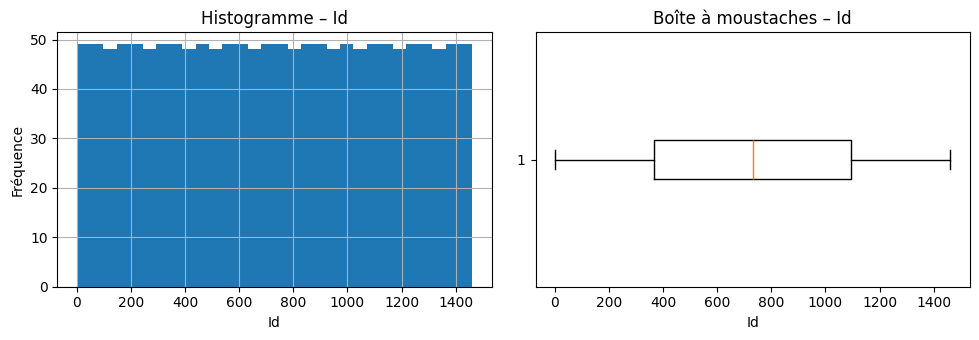

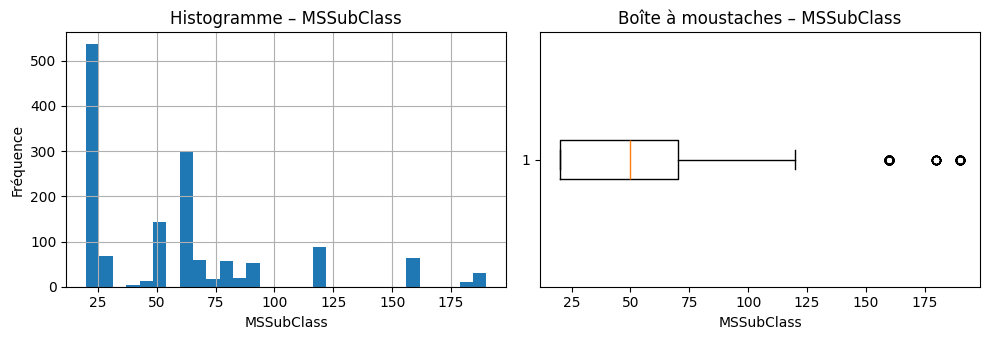

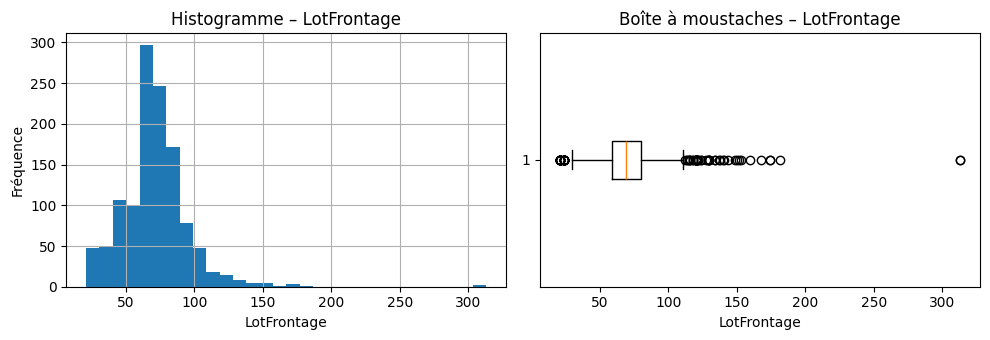

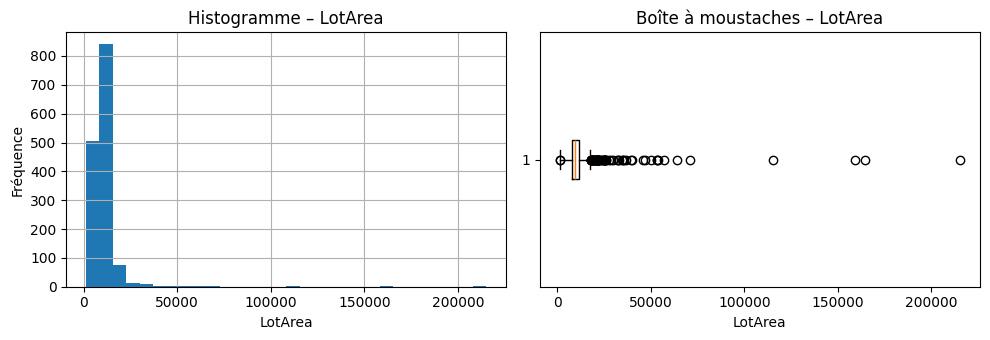

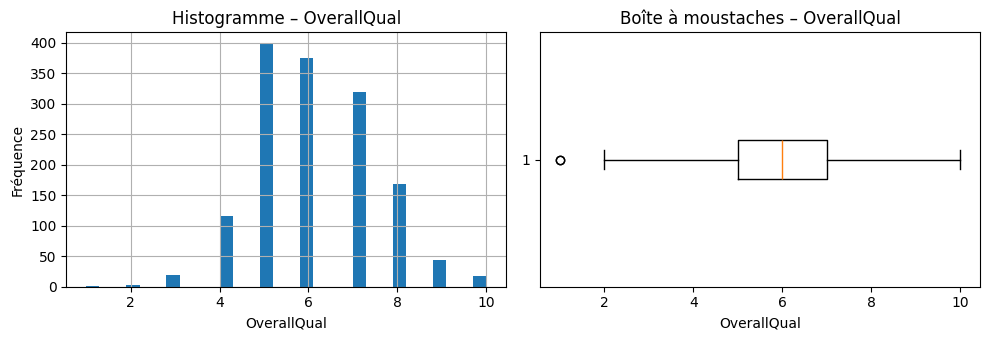

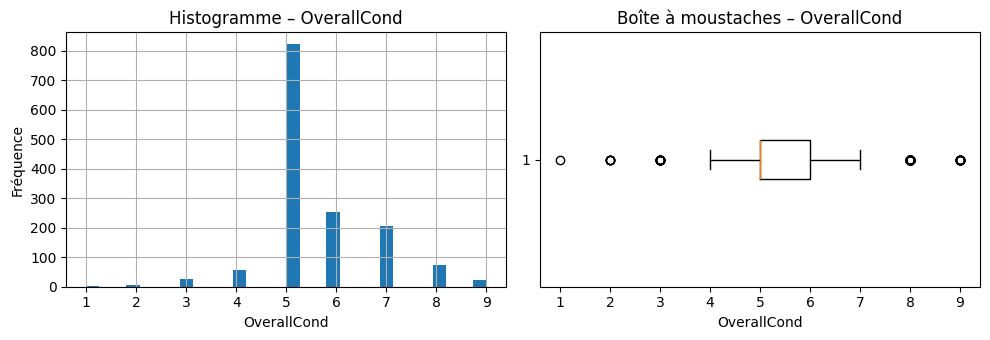

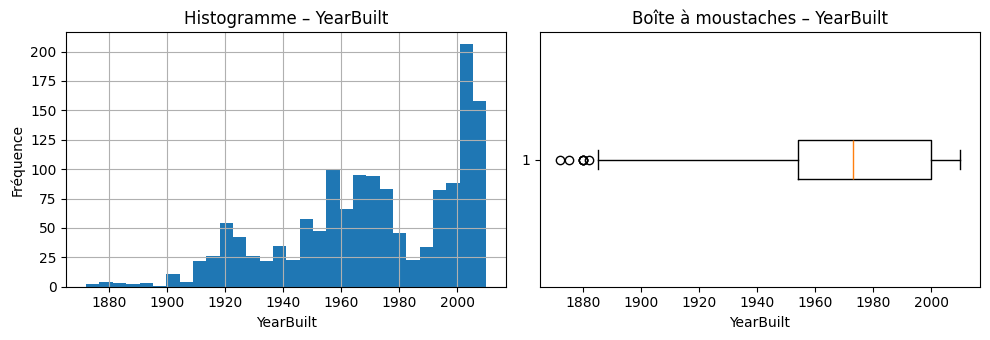

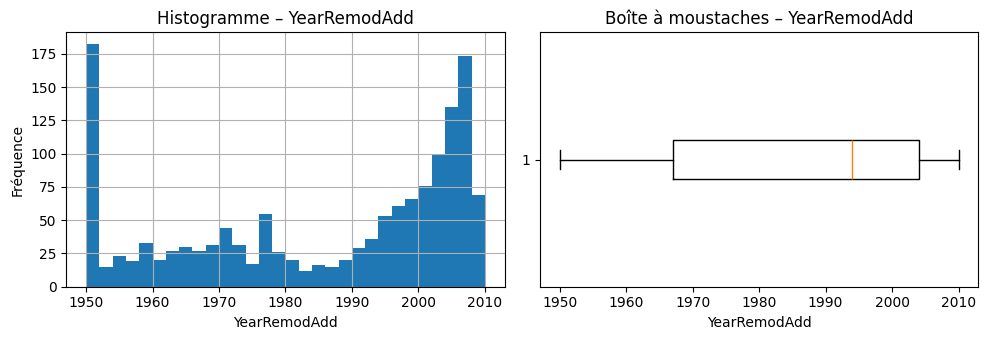

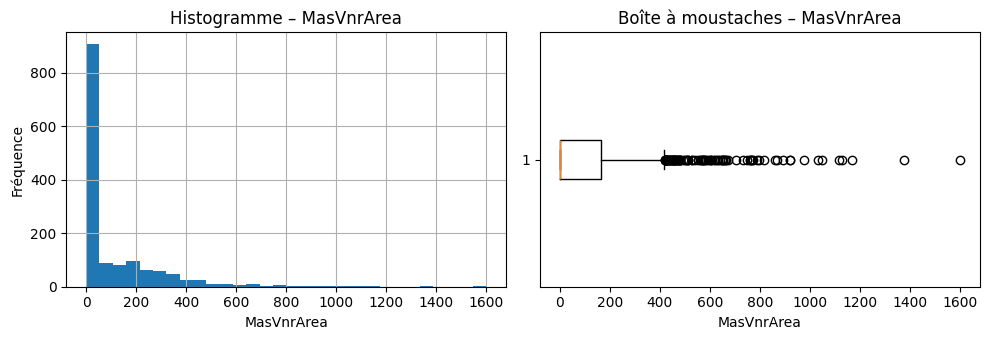

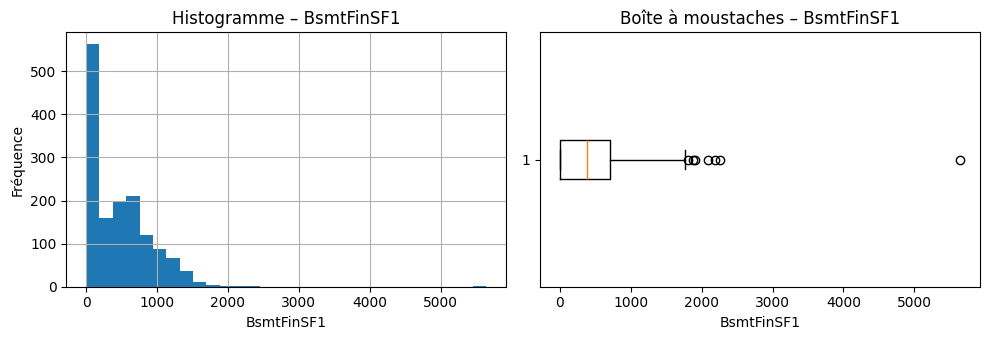

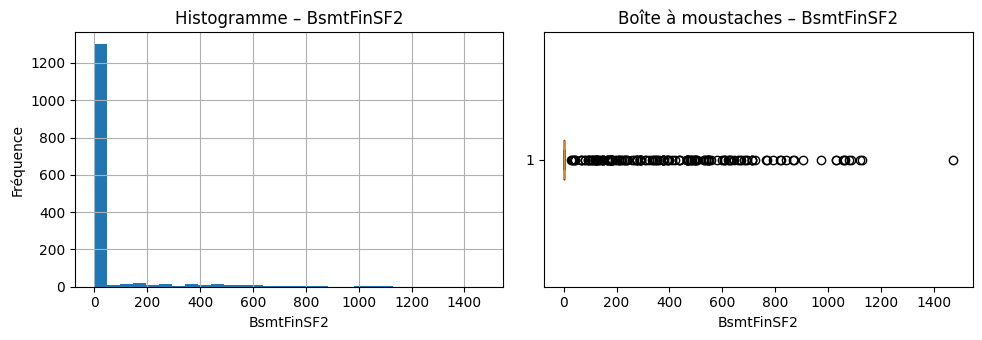

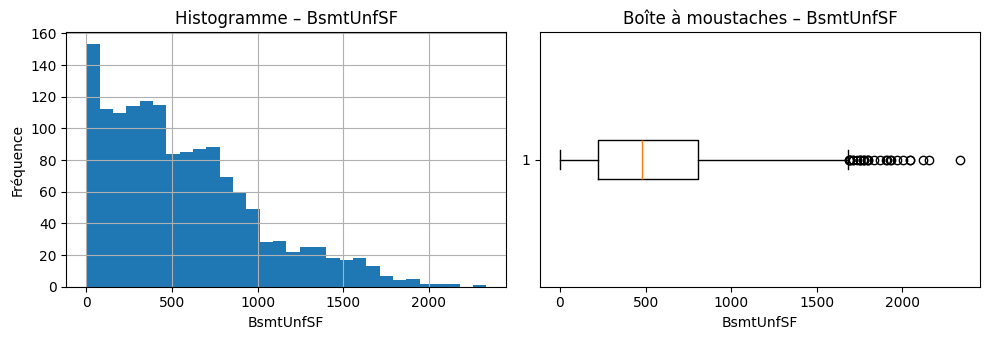

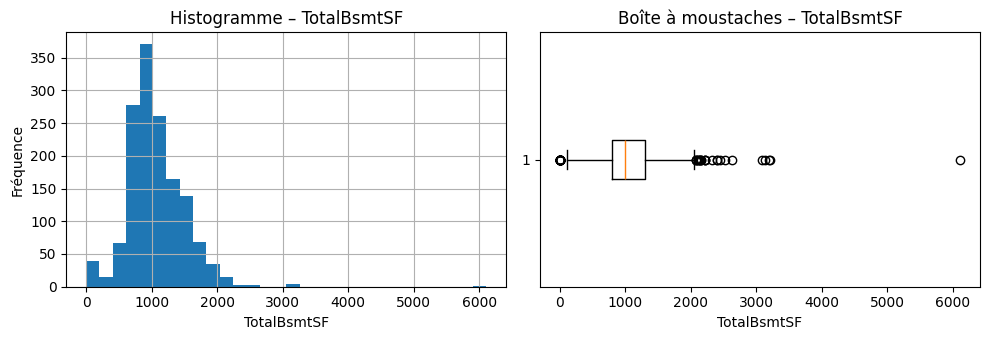

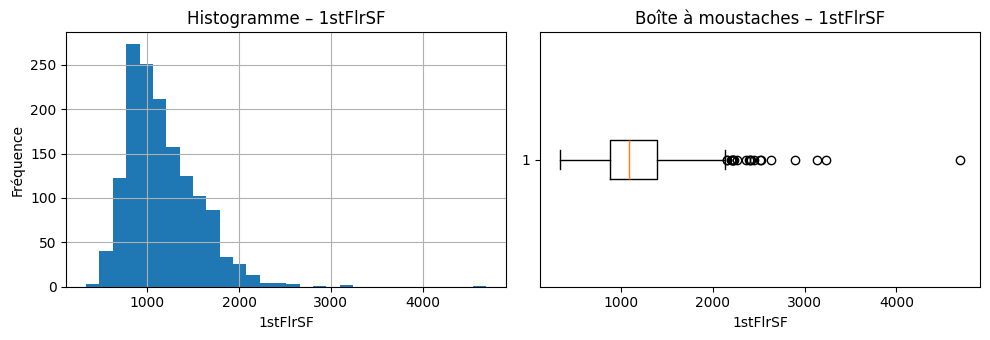

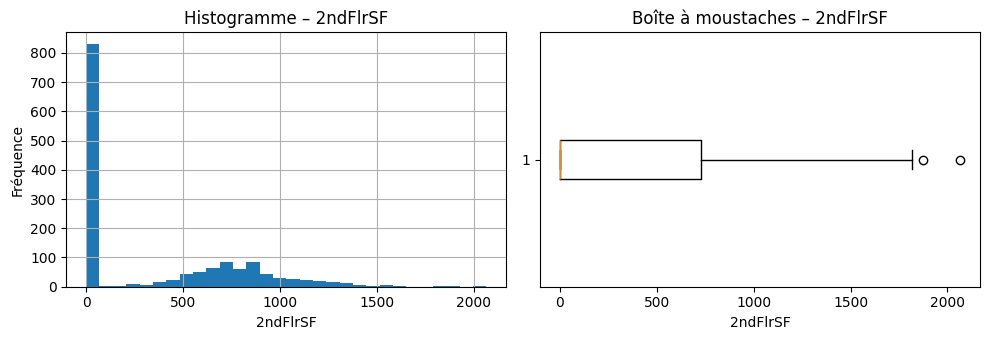

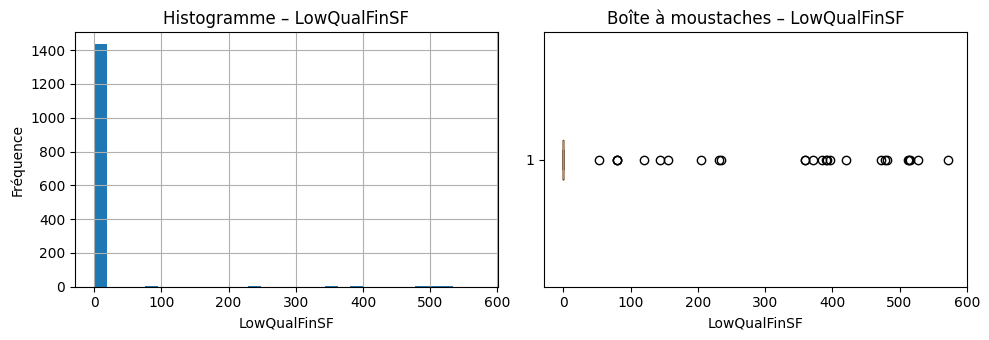

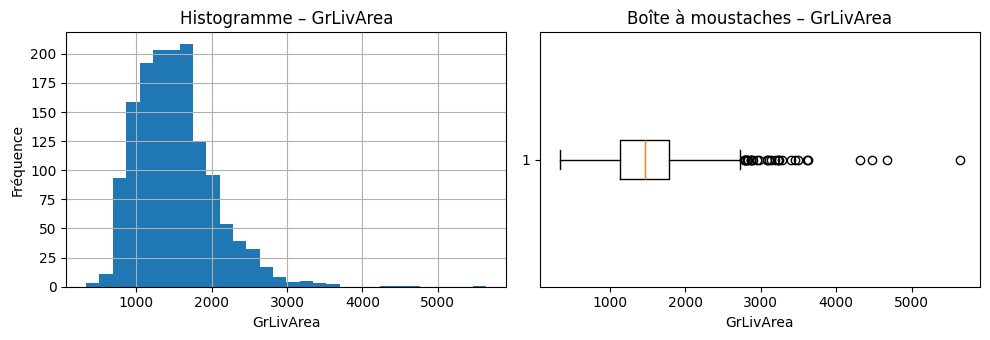

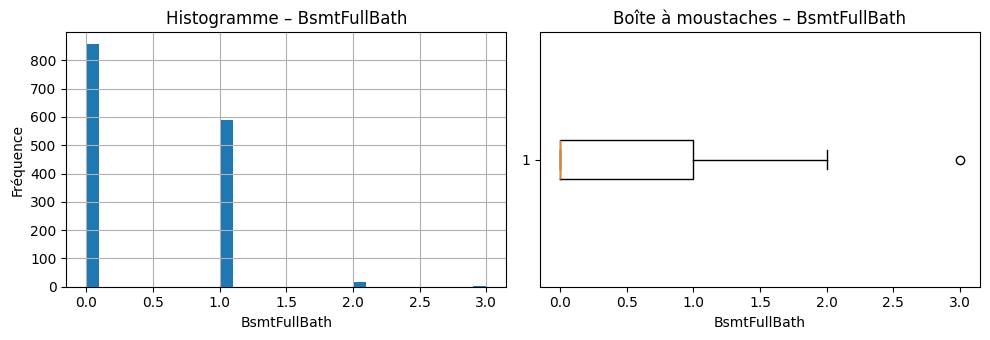

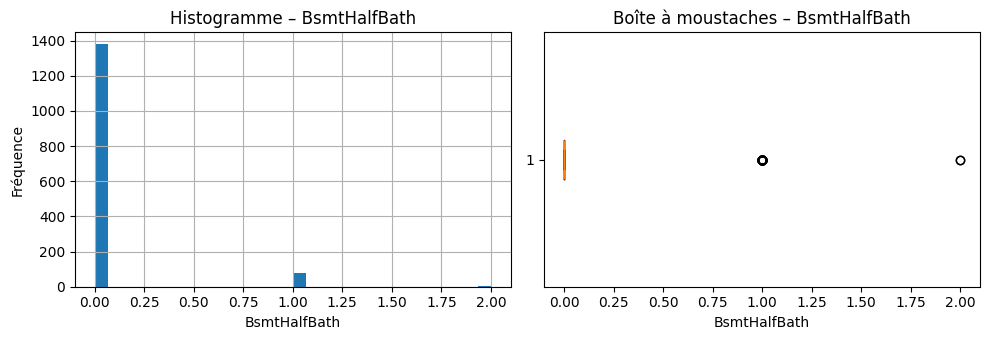

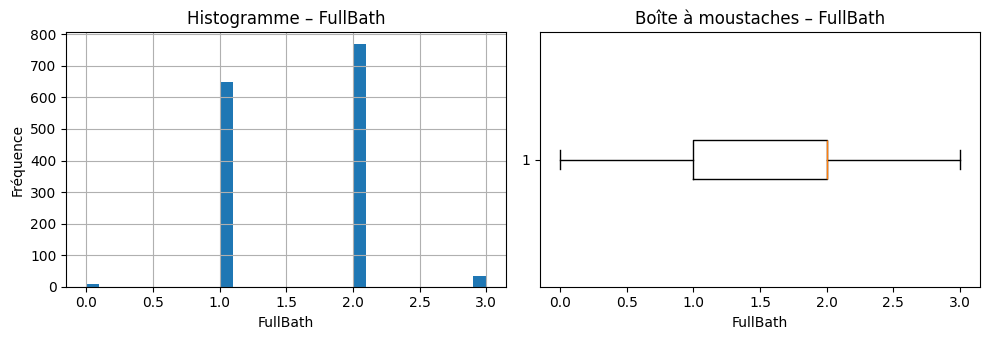

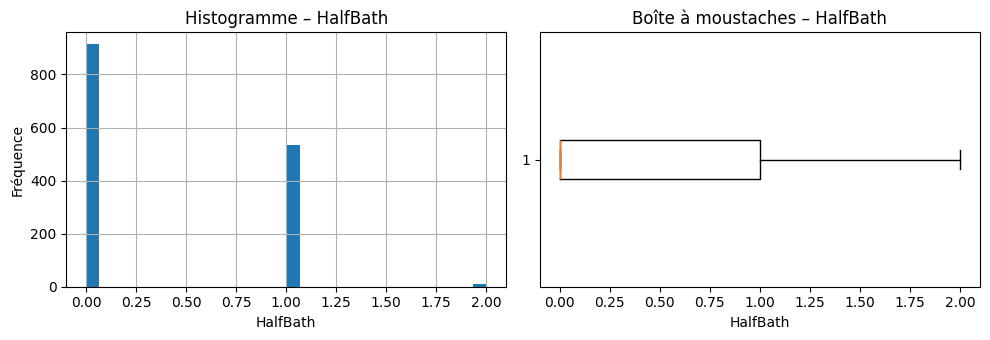

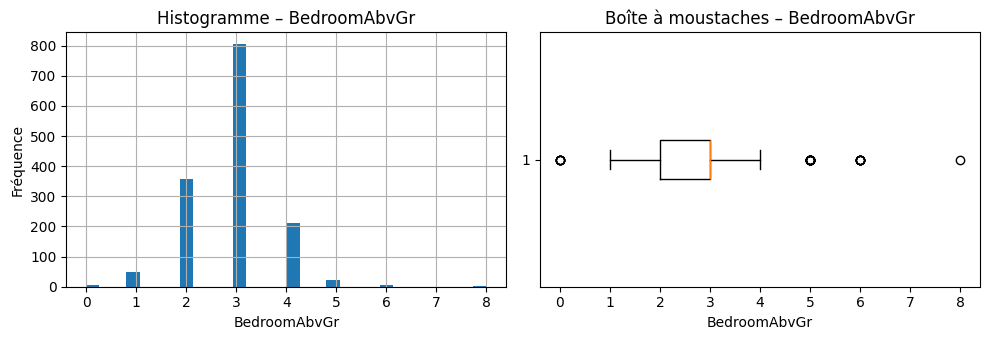

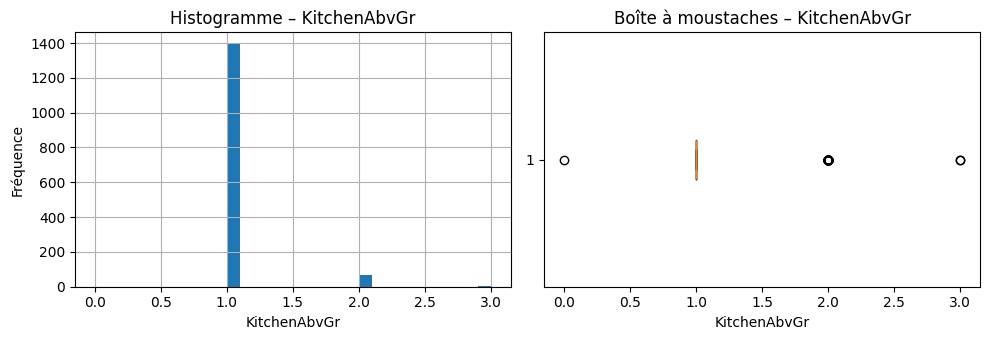

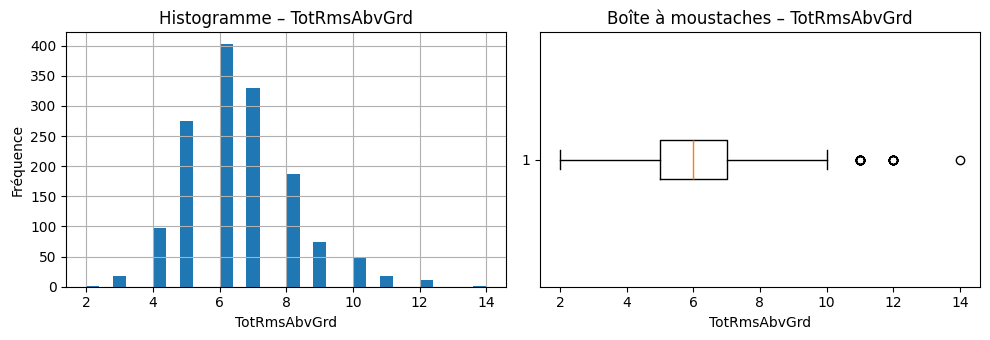

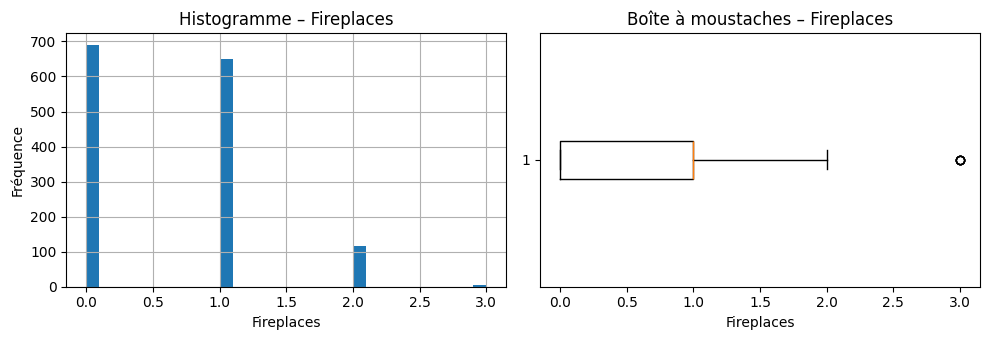

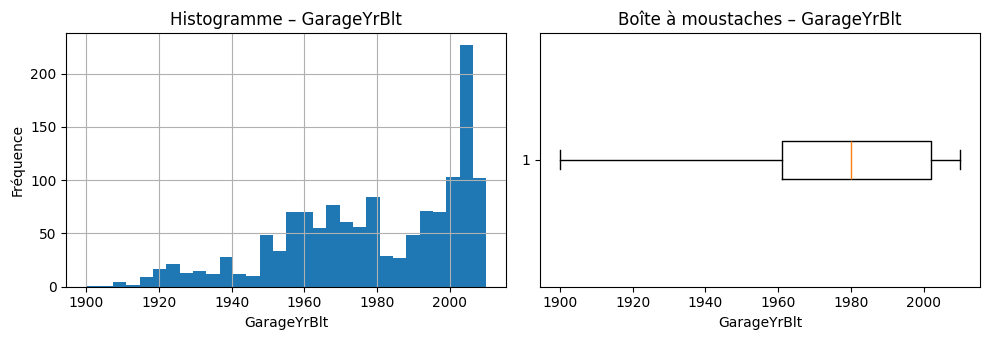

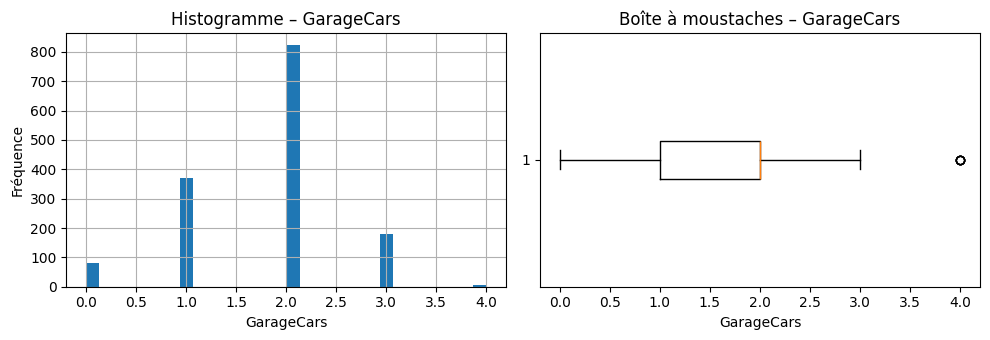

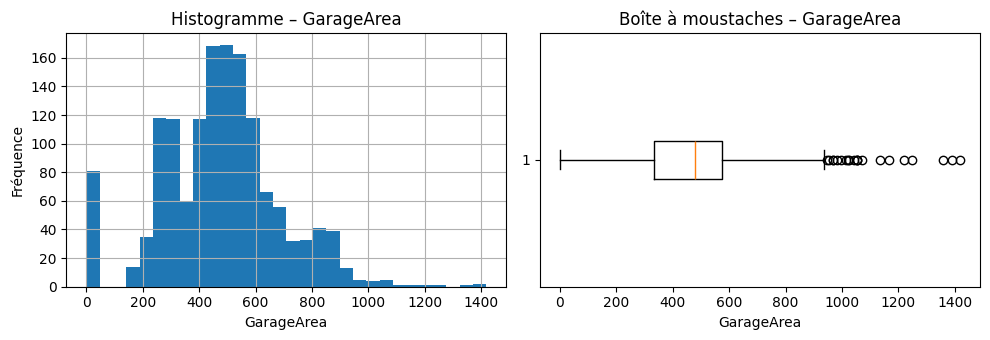

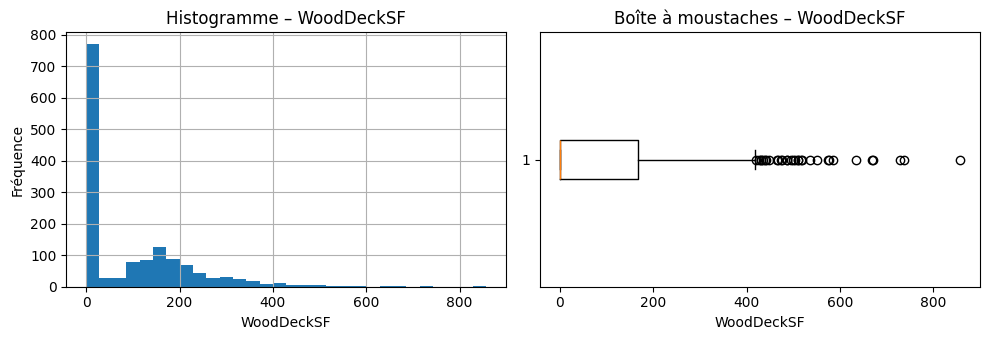

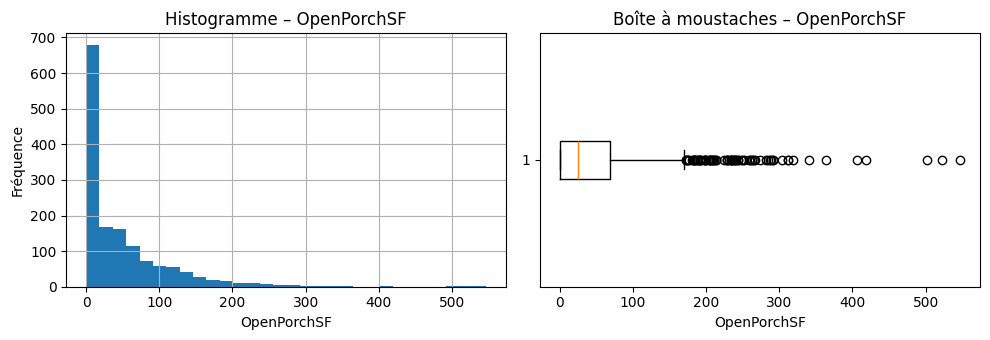

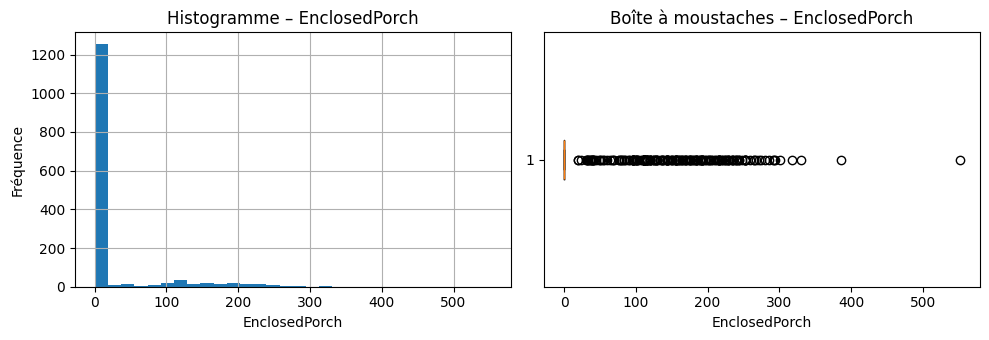

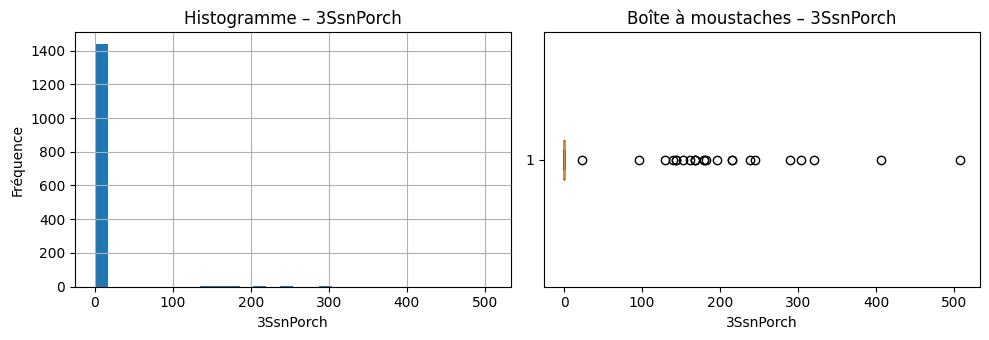

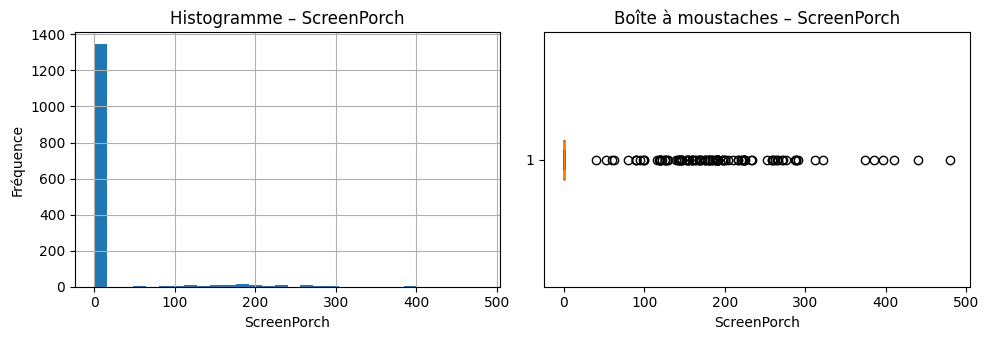

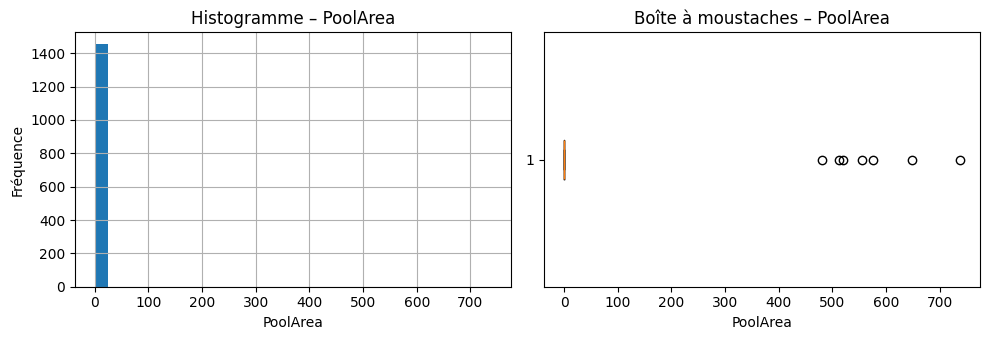

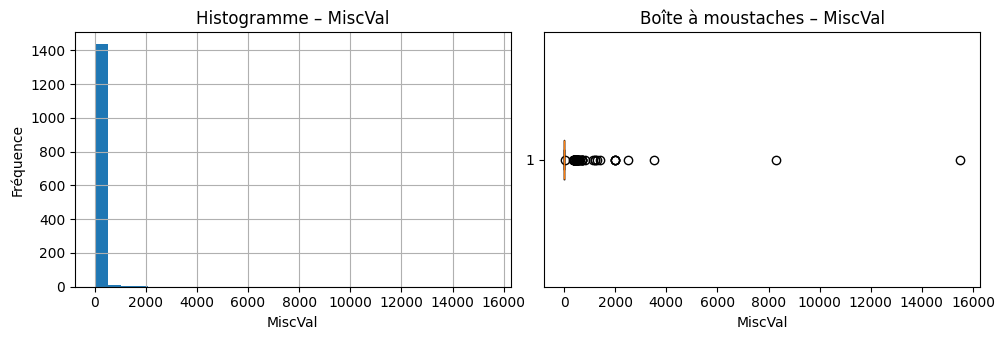

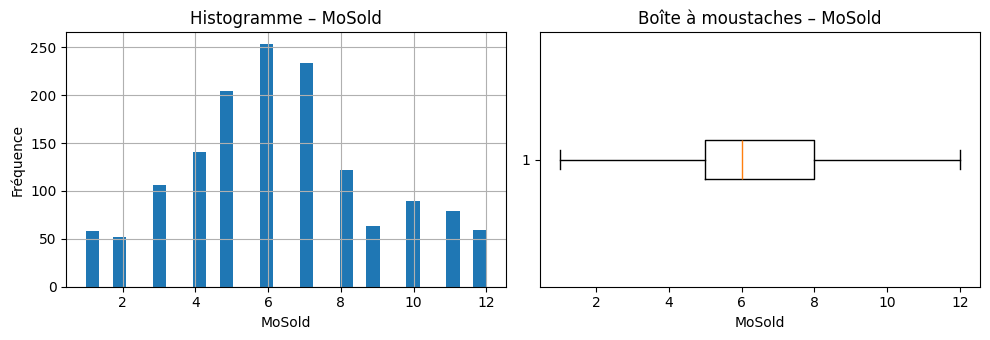

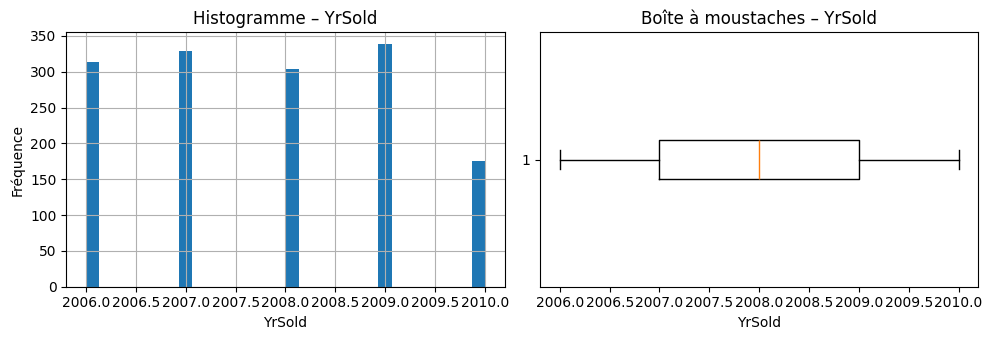

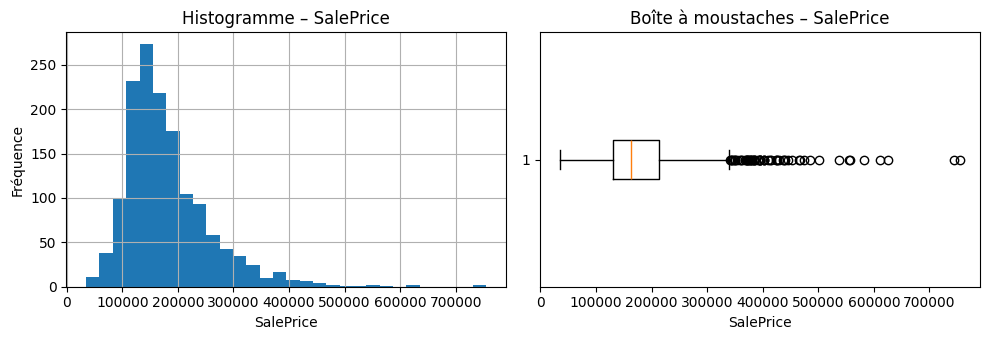

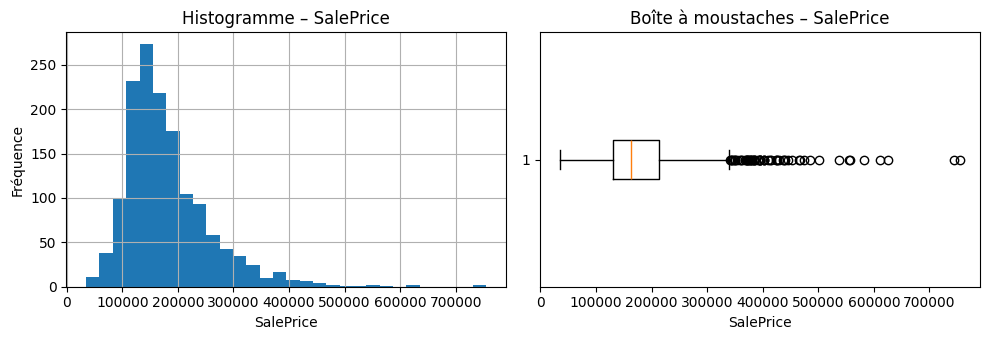

In [10]:
for col in features_numeriques + [cible]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    df[col].hist(bins=30, ax=axes[0])
    axes[0].set_title(f"Histogramme – {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Fréquence")

    axes[1].boxplot(df[col].dropna(), vert=False)
    axes[1].set_title(f"Boîte à moustaches – {col}")
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()


**INTERPRÉTATION — Distributions :**

**Variables de qualité :**
- `OverallQual` : distribution approximativement normale centrée sur 5–7 → bonne représentativité de l'échantillon sur toute la plage de qualité
- `OverallCond` : pic en 5 (état moyen) → moins discriminant que la qualité

**Variables temporelles :**
- `YearBuilt` : bimodale avec un pic dans les années 1950–1960 et un second dans les années 2000 → deux générations de construction à Ames, Iowa
- `YearRemodAdd` : concentré après 1990 → vague de rénovations récentes

**Variables de surface :**
- `GrLivArea`, `TotalBsmtSF`, `GarageArea` : légèrement asymétriques à droite, boîtes à moustaches montrant quelques points extrêmes → légitimes
- `2ndFlrSF`, `WoodDeckSF`, `OpenPorchSF` : masse en 0 puis longue queue → distributions **zero-inflated** ; envisager une variable binaire `HasSecondFloor`, `HasDeck`…

**Variables quasi-constantes ou très concentrées :**
- `PoolArea`, `MiscVal`, `3SsnPorch` : > 95 % des valeurs à 0 → peu d'information pour un modèle seul ; à combiner ou binariser

**Variable cible :**
- `SalePrice` : asymétrie droite confirmée (1.88) → histogramme en cloche décalée
- Après `log1p` : distribution proche de la normale → améliore les conditions d'application des modèles linéaires et réduit l'influence des biens de luxe

**CONCLUSION :**
- Transformer `SalePrice` en `log1p(SalePrice)` → priorité absolue
- Créer des indicateurs binaires pour les variables zero-inflated
- Appliquer `RobustScaler` sur les variables de surface


## 7. Analyses de corrélation

On utilise :
- **Pearson** : corrélation linéaire entre variables numériques
- **Spearman** : relation monotone, plus robuste aux valeurs aberrantes
- **Kendall** : association basée sur les rangs
- **Cramér's V** : association entre variables catégorielles
- **ANOVA** : prédicteurs catégoriels vs variable cible continue
- **Information mutuelle** : dépendance non linéaire


Corrélation de Pearson avec la cible :


,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


Corrélation de Spearman avec la cible :


,SalePrice
SalePrice,1.000000
OverallQual,0.809829
GrLivArea,0.731310
GarageCars,0.690711
YearBuilt,0.652682
GarageArea,0.649379
FullBath,0.635957
TotalBsmtSF,0.602725
GarageYrBlt,0.593788
1stFlrSF,0.575408


Corrélation de Kendall avec la cible :


,SalePrice
SalePrice,1.000000
OverallQual,0.669660
GarageCars,0.572168
GrLivArea,0.543942
FullBath,0.518693
GarageArea,0.478146
YearBuilt,0.470960
TotalBsmtSF,0.435018
GarageYrBlt,0.420842
YearRemodAdd,0.412955


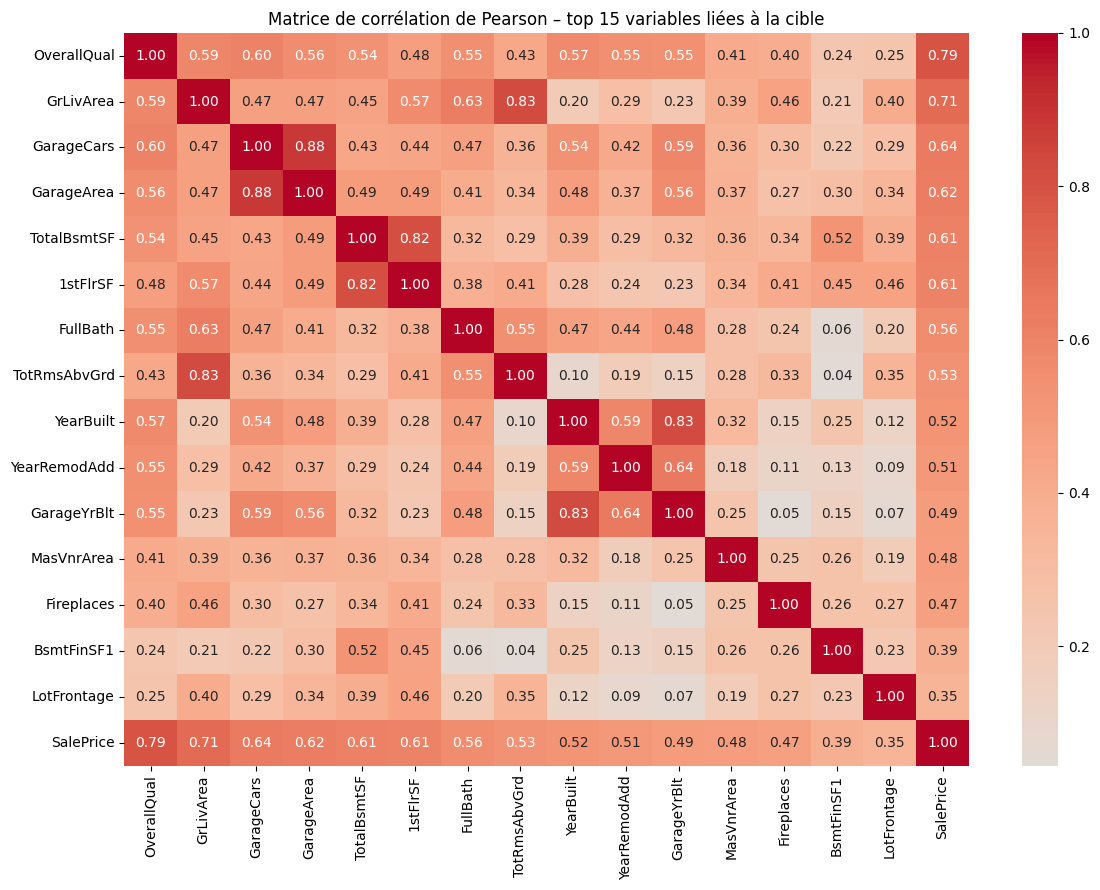

In [11]:
# Colonnes numériques + cible sans doublons
corr_cols = list(dict.fromkeys(features_numeriques + [cible]))

# Matrices de corrélation
corr_pearson  = df[corr_cols].corr(method="pearson")
corr_spearman = df[corr_cols].corr(method="spearman")
corr_kendall  = df[corr_cols].corr(method="kendall")

# Corrélations avec la cible
print("Corrélation de Pearson avec la cible :")
display(corr_pearson[[cible]].sort_values(by=cible, ascending=False))

print("Corrélation de Spearman avec la cible :")
display(corr_spearman[[cible]].sort_values(by=cible, ascending=False))

print("Corrélation de Kendall avec la cible :")
display(corr_kendall[[cible]].sort_values(by=cible, ascending=False))

# Top 15 vraies features les plus corrélées avec la cible selon Pearson
top_features = (
    corr_pearson[cible]
    .drop(cible)
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)

# On ajoute la cible pour l'afficher dans la heatmap
top_cols = top_features + [cible]

plt.figure(figsize=(12, 9))
sns.heatmap(
    df[top_cols].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Matrice de corrélation de Pearson – top 15 variables liées à la cible")
plt.tight_layout()
plt.show()

**INTERPRÉTATION — Corrélations (Pearson / Spearman / Kendall) :**

Les trois méthodes convergent, ce qui valide la robustesse des résultats :

**Top prédicteurs numériques de SalePrice :**
- `OverallQual` (r_pearson ≈ 0.79) : **variable la plus prédictive** — la qualité perçue d'une maison est le facteur dominant du prix, devant la surface
- `GrLivArea` (r ≈ 0.71) : chaque pied carré supplémentaire au-dessus du sol se reflète directement dans le prix
- `GarageCars` / `GarageArea` (r ≈ 0.64 / 0.62) : fortement corrélés entre eux (multicolinéarité) → retenir l'un des deux en modélisation linéaire
- `TotalBsmtSF` / `1stFlrSF` (r ≈ 0.61) : même remarque — redondance partielle avec `GrLivArea`
- `YearBuilt` (r ≈ 0.52) : les constructions récentes valent plus cher, relation monotone confirmée par Spearman

**Faibles corrélateurs :**
- `OverallCond`, `MoSold`, `YrSold`, `BsmtFinSF2` : corrélation < 0.10 avec SalePrice → impact linéaire négligeable, mais ne pas exclure sans test d'information mutuelle

**Multicolinéarité détectée :**
- `GarageCars` ↔ `GarageArea` (r > 0.88), `TotalBsmtSF` ↔ `1stFlrSF` (r > 0.80) → risque de variance excessive dans les modèles linéaires → **feature engineering** : créer `TotalSF = GrLivArea + TotalBsmtSF` et éliminer les redondants

**Cohérence entre méthodes :**
- Pearson légèrement supérieur à Spearman/Kendall → les relations sont principalement **linéaires-monotones**, peu d'effets non linéaires dominants sur les variables numériques
- La convergence des trois méthodes confirme que les outliers n'introduisent pas de biais significatif


**INTERPRÉTATION — V de Cramér (associations entre variables catégorielles) :**

- Les paires avec V > 0.7 correspondent généralement à des variables décrivant le **même élément physique** :
  - `GarageQual` ↔ `GarageCond`, `ExterQual` ↔ `ExterCond`, `BsmtQual` ↔ `BsmtCond` → redondance forte, conserver une seule à titre principal
  - `GarageType` ↔ `GarageFinish` → fortement liés au type de garage
- Les paires avec 0.3 < V < 0.7 révèlent des **associations métiers cohérentes** :
  - `Neighborhood` ↔ `MSZoning` → le quartier détermine en partie le type de zone
  - `BldgType` ↔ `HouseStyle` → le type de bâtiment est lié au style architectural
- **Impact pour la modélisation** : les variables très associées introduiront de la multicolinéarité dans les encodages one-hot → envisager un encoding ciblé ou une sélection de features
- **`Neighborhood`** : V élevé avec plusieurs variables de zone → variable catégorielle très informative, à encoder avec soin (target encoding recommandé face à 25 modalités)


**INTERPRÉTATION — ANOVA (variables catégorielles → SalePrice) :**

- Les variables avec **F-stat élevée et p < 0.05** sont des prédicteurs catégoriels significatifs du prix :
  - `Neighborhood` : F très élevé → le **quartier** est l'un des facteurs catégoriels les plus puissants (localisation prime)
  - `ExterQual`, `KitchenQual`, `BsmtQual` : qualités structurelles fortement différenciantes
  - `GarageFinish`, `Foundation`, `HeatingQC` : impact significatif sur le prix
- Variables avec **faible F-stat ou p > 0.05** : `Street`, `Utilities`, `LandSlope` → distribution trop homogène entre modalités, peu discriminantes
- **Corrélation de rang (Spearman/Kendall) vs Pearson** : la convergence observée dans ce dataset indique que les relations sont majoritairement **monotones** — Pearson est donc valide, mais Spearman reste préférable en présence des outliers de surface

**À retenir :** `Neighborhood`, `OverallQual`, `ExterQual` et `KitchenQual` forment le **cœur prédictif** de ce dataset, côté catégoriel.


In [12]:
def cramers_v(x, y):
    tableau_contingence = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tableau_contingence)[0]
    n    = tableau_contingence.sum().sum()
    r, k = tableau_contingence.shape
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))

resultats_cramers = []
for i, col1 in enumerate(features_categorielles):
    for col2 in features_categorielles[i+1:]:
        temp = df[[col1, col2]].dropna()
        if len(temp) > 0:
            v = cramers_v(temp[col1], temp[col2])
            resultats_cramers.append({"var1": col1, "var2": col2, "cramers_v": round(v, 4)})

df_cramers = pd.DataFrame(resultats_cramers).sort_values("cramers_v", ascending=False)
display(df_cramers.head(20))


C:\Users\Aref Bakali\AppData\Local\Temp\ipykernel_32524\3470510772.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
C:\Users\Aref Bakali\AppData\Local\Temp\ipykernel_32524\3470510772.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
C:\Users\Aref Bakali\AppData\Local\Temp\ipykernel_32524\3470510772.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
C:\Users\Aref Bakali\AppData\Local\Temp\ipykernel_32524\3470510772.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
C:\Users\Aref Bakali\AppData\Local\Temp\ipykernel_32524\3470510772.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
C:\Users\Aref Bakali\AppData\Local\Temp\ipykernel_32524\3470510772.py:6: RuntimeWarni

,var1,var2,cramers_v
336,Neighborhood,PoolQC,1.0000
852,FireplaceQu,PoolQC,0.8660
895,PoolQC,SaleCondition,0.8498
761,BsmtFinType2,PoolQC,0.8416
88,Alley,Neighborhood,0.8020
666,Foundation,PoolQC,0.7817
524,Exterior1st,Exterior2nd,0.7620
1,MSZoning,Alley,0.7439
744,BsmtFinType1,PoolQC,0.7169
572,Exterior2nd,PoolQC,0.7169


In [13]:
resultats_anova = []
for col in features_categorielles:
    temp   = df[[col, cible]].dropna()
    groupes = [g[cible].values for _, g in temp.groupby(col)]
    if len(groupes) >= 2:
        f_stat, p_valeur = stats.f_oneway(*groupes)
        resultats_anova.append({"feature": col, "stat_F": round(f_stat, 2), "p_valeur": round(p_valeur, 4)})

df_anova = pd.DataFrame(resultats_anova).sort_values("stat_F", ascending=False)
display(df_anova)


,feature,stat_F,p_valeur
18,ExterQual,443.33,0.0000
30,KitchenQual,407.81,0.0000
21,BsmtQual,392.91,0.0000
34,GarageFinish,250.96,0.0000
20,Foundation,100.25,0.0000
28,CentralAir,98.31,0.0000
27,HeatingQC,88.39,0.0000
8,Neighborhood,71.78,0.0000
33,GarageType,71.52,0.0000
23,BsmtExposure,70.89,0.0000


In [14]:
from sklearn.feature_selection import mutual_info_regression

entree_mi = df[features_numeriques].copy()
for col in entree_mi.columns:
    entree_mi[col] = entree_mi[col].fillna(entree_mi[col].median())

mi = mutual_info_regression(entree_mi, df[cible], random_state=42)
df_mi = pd.DataFrame({"feature": features_numeriques, "information_mutuelle": mi}).sort_values("information_mutuelle", ascending=False)
display(df_mi)

,feature,information_mutuelle
37,SalePrice,5.578555
4,OverallQual,0.567223
16,GrLivArea,0.483276
26,GarageCars,0.372574
6,YearBuilt,0.372126
12,TotalBsmtSF,0.368115
27,GarageArea,0.363512
13,1stFlrSF,0.310539
25,GarageYrBlt,0.293929
1,MSSubClass,0.271101


## 8. Tests statistiques avant modélisation

- Test de normalité sur la variable cible (SalePrice)



count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


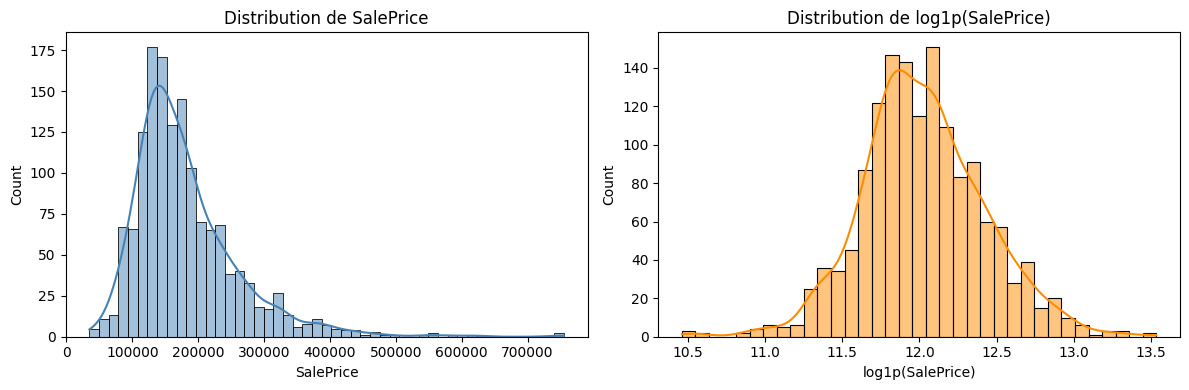

In [15]:
# Statistiques descriptives
print(df['SalePrice'].describe())

# Histogramme de SalePrice
afig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution de SalePrice')
axes[0].set_xlabel('SalePrice')

# Transformation logarithmique
saleprice_log = np.log1p(df['SalePrice'])
sns.histplot(saleprice_log, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution de log1p(SalePrice)')
axes[1].set_xlabel('log1p(SalePrice)')

plt.tight_layout()
plt.show()

### INTERPRÉTATION — Normalité de SalePrice et transformation log1p

**Distribution originale :**
- Asymétrie = 1.88 (queue droite longue) et kurtosis = 6.54 (queue lourde) → **non normale**
- Conséquences pratiques : résidus non gaussiens dans les modèles linéaires, métriques RMSE fortement influencées par les biens de luxe

**Après transformation `log1p(SalePrice)` :**
- Distribution nettement plus symétrique, asymétrie ramenée vers 0.1–0.2
- Kurtosis proche de 3 (queues légères) → conditions de normalité quasi-satisfaites
- Les résidus des modèles linéaires seront mieux distribués → intervalles de confiance et tests d'hypothèse plus fiables

**Décision :** travailler avec `log1p(SalePrice)` comme cible de modélisation ; penser à appliquer `np.expm1()` pour retrouver les prix réels lors de l'évaluation finale.



## 9. Synthèse EDA — Décisions clés pour la modélisation

### Ce que l'EDA a révélé

| Dimension | Constat | Action recommandée |
|---|---|---|
| **Variable cible** | SalePrice non normale, asymétrie 1.88 | Transformer en `log1p(SalePrice)` |
| **Valeurs manquantes** | Principalement structurelles (absence = 0) | `'None'` / `0` + médiane/mode pour le reste |
| **Outliers** | Légitimes (rares mais réels) | Conserver + `RobustScaler` |
| **Multicolinéarité** | GarageCars↔GarageArea, TotalBsmtSF↔1stFlrSF | Feature engineering (`TotalSF`) |
| **Variables zero-inflated** | 2ndFlrSF, WoodDeckSF, PoolArea… | Créer indicateurs binaires `Has_X` |
| **Variables temporelles** | YearBuilt, YearRemodAdd | Créer `Age` et `YearsSinceRemod` |
| **Top prédicteurs** | OverallQual, GrLivArea, Neighborhood | Priorité dans le feature selection |


